# Analisis Sentimen Review Produk Hiburan Menggunakan IndoBERT
**Deskripsi Proyek:** Proyek ini bertujuan membangun model Sentiment Analysis pada ulasan produk kategori hiburan menggunakan model IndoBERT (indobenchmark/indobert-base-p1) untuk mengklasifikasikan sentimen menjadi tiga kelas, yaitu positif, netral, dan negatif. Tahapan yang dilakukan meliputi Exploratory Data Analysis (EDA), preprocessing teks tanpa menggunakan Sastrawi, pelabelan menggunakan target asli dataset, tokenisasi, pelatihan model menggunakan class weight, evaluasi performa menggunakan Accuracy, Macro F1, Weighted F1, Error Analysis, Inference, serta penyimpanan model ke format .pkl. Model terbaik menggunakan konfigurasi learning rate 1e-5, batch size 16, epoch 6, dan warmup step 100 dengan hasil Accuracy sebesar 88,76%, Macro F1 sebesar 74,17%, dan Weighted F1 sebesar 88,98%.

# A. Import Library

In [18]:
!pip install pandas numpy scikit-learn transformers torch accelerate matplotlib -q

import pandas as pd
import numpy as np
import re
import os
import ast
import pickle
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import html

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# B. Load Data Scraping

In [19]:
base_path = "/kaggle/input/datasets/adindaintanerlita/sentiment-hiburan/"

df = pd.read_csv(
    base_path + "hiburan.csv"
)

with open(
    base_path + "slangwords.csv",
    "r",
    encoding="utf-8"
) as f:
    slang_dict = ast.literal_eval(f.read())

print(df.head())
print("Jumlah data:", len(df))
print(df.info())
print(df.isnull().sum())

                                                name category  \
0  Gramedia - Buku Novel Funiculi Funicula (Buku ...     buku   
1                   Rich Dad Poor Dad (Edisi Revisi)     buku   
2                          Buku Berani Tidak Disukai     buku   
3                          Buku Berani Tidak Disukai     buku   
4  Renebook - The Decision Book Lima Puluh Pola P...     buku   

                                              review  rating    target  
0  Udah sampai dengan selamat. Packagingnya rapi ...       5  Positive  
1                                                 Ok       5  Positive  
2                                      Dijamin Ori👍🏻       5  Positive  
3                                       buku nya ori       5  Positive  
4  Bagus, bukunya kualitas cetak nya bagus. Pengi...       5  Positive  
Jumlah data: 10000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  --

# C. Exploratory Data Analysis (EDA)

Ukuran dataset: (10000, 5)

Nama kolom:
Index(['name', 'category', 'review', 'rating', 'target'], dtype='object')

Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      10000 non-null  object
 1   category  10000 non-null  object
 2   review    10000 non-null  object
 3   rating    10000 non-null  int64 
 4   target    10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB
None

Jumlah missing value:
name        0
category    0
review      0
rating      0
target      0
dtype: int64

Jumlah duplikasi:
0

Distribusi rating:
rating
1    1092
2     451
3     938
4     310
5    7209
Name: count, dtype: int64

Distribusi kategori:
category
buku                7858
film_musik           927
gaming               790
Books                113
Toys and Hobbies     112
Movies and Music     100
Gaming               100
Name:

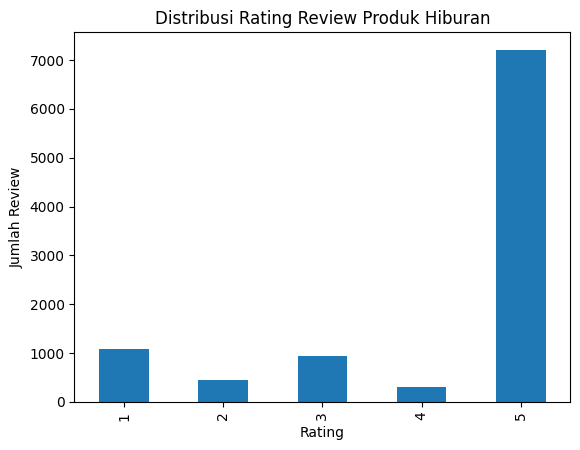

In [20]:
print("Ukuran dataset:", df.shape)
print("\nNama kolom:")
print(df.columns)

print("\nInfo dataset:")
print(df.info())

print("\nJumlah missing value:")
print(df.isnull().sum())

print("\nJumlah duplikasi:")
print(df.duplicated().sum())

print("\nDistribusi rating:")
print(df["rating"].value_counts().sort_index())

print("\nDistribusi kategori:")
print(df["category"].value_counts())

if "target" in df.columns:
    print("\nDistribusi target:")
    print(df["target"].value_counts())

df["review_length"] = df["review"].astype(str).apply(len)
df["word_count"] = df["review"].astype(str).apply(lambda x: len(x.split()))

print("\nStatistik panjang review:")
print(df[["review_length", "word_count"]].describe())

df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribusi Rating Review Produk Hiburan")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.show()

# D. Preprocessing

In [21]:
emoji_dict = {
    "😊": "senang", "😁": "senang", "😍": "suka",
    "🥰": "suka", "😭": "kecewa", "😢": "sedih",
    "😡": "marah", "😤": "kesal", "🤩": "senang",
    "🔥": "bagus", "👍": "bagus", "👎": "jelek",
    "💔": "kecewa", "❤️": "suka", "❤": "suka"
}

def clean_text(text):

    text = str(text).lower()

    text = html.unescape(text)

    text = re.sub(r'\\n|\\t|\\r|\\b|\\f|\\v', ' ', text)
    text = re.sub(r'\\u[0-9a-fA-F]{4}', ' ', text)
    text = re.sub(r'\\x[0-9a-fA-F]{2}', ' ', text)

    text = re.sub(r'http\S+|www\S+', '', text)

    for emo, meaning in emoji_dict.items():
        text = text.replace(emo, " " + meaning + " ")

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    words = text.split()
    words = [slang_dict.get(w, w) for w in words]

    text = " ".join(words)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df = df.dropna(subset=["review"])

df["clean_text"] = df["review"].apply(clean_text)

df = df[df["clean_text"] != ""]

print(df[["review", "clean_text", "rating"]].head())

print("\nKolom dataset:")
print(df.columns)

if "target" in df.columns:
    print("\nDistribusi Target:")
    print(df["target"].value_counts())

                                              review  \
0  Udah sampai dengan selamat. Packagingnya rapi ...   
1                                                 Ok   
2                                      Dijamin Ori👍🏻   
3                                       buku nya ori   
4  Bagus, bukunya kualitas cetak nya bagus. Pengi...   

                                          clean_text  rating  
0  sudah sampai dengan selamat packagingnya rapi ...       5  
1                                                oke       5  
2                                  dijamin ori bagus       5  
3                                       buku nya ori       5  
4  bagus bukunya kualitas cetak nya bagus pengiri...       5  

Kolom dataset:
Index(['name', 'category', 'review', 'rating', 'target', 'review_length',
       'word_count', 'clean_text'],
      dtype='object')

Distribusi Target:
target
Positive    7490
Negative    1535
Neutral      933
Name: count, dtype: int64


# E. Labeling

In [22]:
df["sentiment"] = df["target"].str.lower()

df["sentiment"] = df["sentiment"].replace({
    "positive": "positif",
    "neutral": "netral",
    "negative": "negatif"
})

print("Distribusi Sentimen:")
print(df["sentiment"].value_counts())

Distribusi Sentimen:
sentiment
positif    7490
negatif    1535
netral      933
Name: count, dtype: int64


# E1. Label Encoding

In [23]:
sentiment_labels = sorted(df["sentiment"].unique())

label_map = {
    label: i
    for i, label in enumerate(sentiment_labels)
}

sentiment_map = {
    v: k
    for k, v in label_map.items()
}

df["label"] = df["sentiment"].map(label_map)

print("Label Map:")
print(label_map)

Label Map:
{'negatif': 0, 'netral': 1, 'positif': 2}


# F. Split Data

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Distribusi Train:")
print(y_train.value_counts())

print("\nDistribusi Test:")
print(y_test.value_counts())

Distribusi Train:
label
2    5992
0    1228
1     746
Name: count, dtype: int64

Distribusi Test:
label
2    1498
0     307
1     187
Name: count, dtype: int64


# G. Tokenizer dan Dataset

In [25]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)

lengths = df["clean_text"].str.split().apply(len)

max_len = int(np.percentile(lengths, 95))
max_len = min(max_len, 128)

print("Max Length:", max_len)

train_enc = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=max_len
)

test_enc = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=max_len
)

class SentimentDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {
            k: torch.tensor(v[idx])
            for k, v in self.encodings.items()
        }

        item["labels"] = torch.tensor(self.labels[idx])

        return item

    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_enc, y_train)
test_dataset = SentimentDataset(test_enc, y_test)

Max Length: 30


# H. Class Weight

In [26]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

print("Class Weights:", class_weights)

Class Weights: tensor([2.1623, 3.5594, 0.4431])


# I. Mertics

In [27]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

# J. Custom Trainer dengan Class Weight

In [28]:
class WeightedTrainer(Trainer):

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs.pop("labels")

        outputs = model(**inputs)

        logits = outputs.logits if hasattr(outputs, "logits") else outputs[0]

        weights = class_weights.to(logits.device)

        loss_fct = nn.CrossEntropyLoss(weight=weights)

        num_labels = logits.shape[-1]

        loss = loss_fct(
            logits.view(-1, num_labels),
            labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

# K. Training

In [29]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(sentiment_labels),
    id2label={
        idx: label
        for idx, label in enumerate(sentiment_labels)
    },
    label2id={
        label: idx
        for idx, label in enumerate(sentiment_labels)
    },
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir="./results_hiburan_best_v4",

    learning_rate=1e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=6,

    eval_strategy="epoch",
    save_strategy="epoch",

    save_total_limit=1,

    load_best_model_at_end=True,

    metric_for_best_model="f1_macro",
    greater_is_better=True,

    logging_steps=100,

    warmup_steps=100,

    weight_decay=0.01,

    fp16=torch.cuda.is_available(),

    report_to="none"
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=test_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

trainer.train()

eval_result = trainer.evaluate()

print("\nHASIL EVALUASI:")
print(eval_result)

best_model = trainer.model

best_result = {
    "learning_rate": 1e-5,
    "batch_size": 16,
    "epoch": 6,
    "warmup_steps": 100,
    "accuracy": eval_result["eval_accuracy"],
    "f1_weighted": eval_result["eval_f1_weighted"],
    "f1_macro": eval_result["eval_f1_macro"]
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted,F1 Macro
1,0.601577,0.591582,0.824799,0.846156,0.681751
2,0.485671,0.617294,0.867470,0.874070,0.711814
3,0.392689,0.608867,0.871486,0.879629,0.725867
4,0.264751,0.708428,0.885040,0.889127,0.740877
5,0.211702,0.826905,0.886546,0.889706,0.738947
6,0.141574,0.905992,0.887550,0.889808,0.741713


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


HASIL EVALUASI:
{'eval_loss': 0.9059920907020569, 'eval_accuracy': 0.8875502008032129, 'eval_f1_weighted': 0.8898077522418327, 'eval_f1_macro': 0.7417134594007194, 'eval_runtime': 4.6502, 'eval_samples_per_second': 428.373, 'eval_steps_per_second': 13.548, 'epoch': 6.0}


# L. Evaluasi Model Terbaik

In [30]:
best_model = trainer.model
best_model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
best_model.to(device)

all_preds = []
all_labels = []

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

with torch.no_grad():
    for batch in test_loader:
        labels = batch["labels"].cpu().numpy()

        batch = {
            k: v.to(device)
            for k, v in batch.items()
        }

        outputs = best_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"]
        )

        preds = torch.argmax(
            outputs.logits,
            dim=1
        ).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print("\nCLASSIFICATION REPORT:")
print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(sentiment_labels))),
    target_names=sentiment_labels
))

print("\nCONFUSION MATRIX:")
print(confusion_matrix(y_true, y_pred))

print("\nF1-SCORE PER CLASS:")
f1_per_class = f1_score(
    y_true,
    y_pred,
    average=None
)

for label, score in zip(sentiment_labels, f1_per_class):
    status = "AMAN" if score >= 0.75 else "PERLU DITINGKATKAN"
    print(f"{label:10s}: F1 = {score:.4f} | {status}")

print(f"\nAccuracy   : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1   : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_true, y_pred, average='weighted'):.4f}")


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

     negatif       0.78      0.75      0.76       307
      netral       0.47      0.53      0.50       187
     positif       0.97      0.96      0.96      1498

    accuracy                           0.89      1992
   macro avg       0.74      0.75      0.74      1992
weighted avg       0.89      0.89      0.89      1992


CONFUSION MATRIX:
[[ 230   64   13]
 [  55   99   33]
 [  11   48 1439]]

F1-SCORE PER CLASS:
negatif   : F1 = 0.7629 | AMAN
netral    : F1 = 0.4975 | PERLU DITINGKATKAN
positif   : F1 = 0.9648 | AMAN

Accuracy   : 0.8876
Macro F1   : 0.7417
Weighted F1: 0.8898


# M.  Error Analysis

In [31]:
error_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_true,
    "pred_label": y_pred
})

error_df["true_sentiment"] = error_df["true_label"].map(sentiment_map)
error_df["pred_sentiment"] = error_df["pred_label"].map(sentiment_map)

wrong_predictions = error_df[
    error_df["true_sentiment"] != error_df["pred_sentiment"]
]

print("\nJUMLAH SALAH PREDIKSI:", len(wrong_predictions))
print(wrong_predictions.head(10))

print("\nPola kesalahan prediksi:")
print(
    wrong_predictions
    .groupby(["true_sentiment", "pred_sentiment"])
    .size()
)


JUMLAH SALAH PREDIKSI: 224
                                                 text  true_label  pred_label  \
25  ini cm sial saja kali iya saya dapat yang minu...           2           1   
26                          cepat respon terima kasih           1           2   
29  seperti biasa pelayanannya bagus tapi sayang t...           2           1   
40                                        beli datang           0           2   
46                                              tipis           0           1   
47     isinya dasar semua cocok sih kalau buat pemula           1           2   
52  tidak bisa di colok ke seluler seluler saya pa...           1           0   
59  dari segi material bukunya kurang oke lembaran...           2           1   
68  ada static noise yang sangat kentara baik saat...           0           1   
89  beli yang satu lancar satunya lagi neken tombo...           1           0   

   true_sentiment pred_sentiment  
25        positif         netral  
26        

# N. Inferene

In [32]:
def predict_sentiment(text, show_confidence=False):

    text_clean = clean_text(text)

    encoding = tokenizer(
        [text_clean],
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=max_len
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    best_model.to(device)
    best_model.eval()

    encoding = {
        k: v.to(device)
        for k, v in encoding.items()
    }

    with torch.no_grad():
        output = best_model(**encoding)

    pred = torch.argmax(
        output.logits,
        dim=1
    ).item()

    if show_confidence:
        probs = torch.softmax(
            output.logits,
            dim=1
        ).squeeze().tolist()

        print("\nConfidence per kelas:")

        for label, prob in zip(sentiment_labels, probs):
            print(f"{label:10s}: {prob:.2%}")

    return sentiment_map[pred]


test_samples = [
    "Filmnya bagus banget, ceritanya seru dan kualitasnya memuaskan",
    "Produknya biasa saja, tidak terlalu menarik tapi masih bisa digunakan",
    "Barangnya rusak, kualitas buruk, dan sangat mengecewakan"
]

print("\nHASIL INFERENCE:")

for sample in test_samples:
    hasil = predict_sentiment(
        sample,
        show_confidence=True
    )

    print("\nTeks     :", sample)
    print("Sentimen :", hasil)
    print("-" * 50)


HASIL INFERENCE:

Confidence per kelas:
negatif   : 0.10%
netral    : 0.13%
positif   : 99.77%

Teks     : Filmnya bagus banget, ceritanya seru dan kualitasnya memuaskan
Sentimen : positif
--------------------------------------------------

Confidence per kelas:
negatif   : 0.32%
netral    : 99.03%
positif   : 0.65%

Teks     : Produknya biasa saja, tidak terlalu menarik tapi masih bisa digunakan
Sentimen : netral
--------------------------------------------------

Confidence per kelas:
negatif   : 99.60%
netral    : 0.11%
positif   : 0.30%

Teks     : Barangnya rusak, kualitas buruk, dan sangat mengecewakan
Sentimen : negatif
--------------------------------------------------


# O. Simpan Model ke .pkl

In [33]:
SAVE_DIR = "/kaggle/working/model_sentiment_hiburan"

os.makedirs(SAVE_DIR, exist_ok=True)

best_model_cpu = best_model.to("cpu")

best_model_cpu.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

best_result = {
    "learning_rate": 1e-5,
    "batch_size": 16,
    "epoch": 6,
    "warmup_steps": 100,
    "accuracy": accuracy_score(y_true, y_pred),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "f1_macro": f1_score(y_true, y_pred, average="macro")
}

model_bundle = {
    "model_state": best_model_cpu.state_dict(),
    "config": best_model_cpu.config,
    "tokenizer": tokenizer,
    "label_map": label_map,
    "sentiment_map": sentiment_map,
    "max_len": max_len,
    "best_experiment": best_result
}

file_path = "/kaggle/working/model_sentiment_hiburan_indobert.pkl"

with open(file_path, "wb") as f:
    pickle.dump(model_bundle, f)

df_save = df[
    [
        "review",
        "clean_text",
        "rating",
        "sentiment",
        "label"
    ]
]

df_save.to_csv(
    "/kaggle/working/clean_dataset_sentiment_hiburan.csv",
    index=False
)

print("\nMODEL SAVED")
print("File model:", file_path)
print("File dataset bersih: /kaggle/working/clean_dataset_sentiment_hiburan.csv")

print("\nDaftar file di /kaggle/working:")
print(os.listdir("/kaggle/working"))

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


MODEL SAVED
File model: /kaggle/working/model_sentiment_hiburan_indobert.pkl
File dataset bersih: /kaggle/working/clean_dataset_sentiment_hiburan.csv

Daftar file di /kaggle/working:
['.virtual_documents', 'model_sentiment_hiburan', 'model_sentiment_hiburan_indobert.pkl', 'clean_dataset_sentiment_hiburan.csv', 'results_hiburan_best_v4']
